# Обучение трёх ML-моделей

В этом ноутбуке обучаются три модели на основе одного и того же подхода:

- TF-IDF-векторизация текста
- `KNeighborsClassifier`
- косинусная метрика как мера близости текстов

Различие между моделями состоит в размере обучающей выборки:
`100`, `200` и `300` новостей.

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

DATASETS = {
    "100 новостей": "knowledge_base_100 news.csv",
    "200 новостей": "knowledge_base_200 news.csv",
    "300 новостей": "knowledge_base_300 news.csv",
}


def normalize_text(text):
    return " ".join(str(text).lower().replace("\xa0", " ").split())


def build_pipeline():
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    max_features=5000,
                    min_df=2,
                    max_df=0.95,
                    ngram_range=(1, 2),
                ),
            ),
            (
                "model",
                KNeighborsClassifier(
                    n_neighbors=5,
                    metric="cosine",
                    weights="distance",
                ),
            ),
        ]
    )

In [2]:
prepared_datasets = {}

for label, file_name in DATASETS.items():
    frame = pd.read_csv(file_name)
    frame["text_clean"] = frame["text"].apply(normalize_text)
    prepared_datasets[label] = frame

    print("=" * 80)
    print(label)
    print(f"Размер датасета: {frame.shape}")
    print("Распределение по категориям:")
    print(frame["category"].value_counts().sort_index())
    print(frame.head(3))

100 новостей
Размер датасета: (100, 5)
Распределение по категориям:
category
culture      25
economics    25
science      25
sport        25
Name: count, dtype: int64
                                               title  \
0   Кенийский бегун завершил марафон на четвереньках   
1  Зара возмутилась увольнением звезды «Ворониных...   
2  Сыгравший Сильвестра Андреевича актер «Универа...   

                                                text category  \
0  Кенийский бегун Реубен Сива завершил марафон в...    sport   
1  Российская певица Зара (настоящее имя — Зарифа...  culture   
2  Российский актер Алексей Климушкин , известный...  culture   

                                                 url  \
0  https://lenta.ru/news/2026/04/21/keniyskiy-beg...   
1  https://lenta.ru/news/2026/04/21/zara-vozmutil...   
2  https://lenta.ru/news/2026/04/19/sygravshiy-si...   

                                          text_clean  
0  кенийский бегун реубен сива завершил марафон в...  
1  российска

In [3]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = []
trained_models = {}

for label, frame in prepared_datasets.items():
    X = frame["text_clean"]
    y = frame["category"]

    pipeline = build_pipeline()
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")
    pipeline.fit(X, y)

    trained_models[label] = pipeline
    results.append(
        {
            "dataset": label,
            "news_count": len(frame),
            "cv_mean_accuracy": scores.mean(),
            "cv_std_accuracy": scores.std(),
        }
    )

    print("\n" + "=" * 80)
    print(f"Модель для набора: {label}")
    print(f"Точность по 3-fold CV: {scores.mean():.4f}")
    print(f"Стандартное отклонение: {scores.std():.4f}")
    print(f"Все оценки: {scores}")

results_df = pd.DataFrame(results)
results_df


Модель для набора: 100 новостей
Точность по 3-fold CV: 0.7409
Стандартное отклонение: 0.1192
Все оценки: [0.64705882 0.90909091 0.66666667]

Модель для набора: 200 новостей
Точность по 3-fold CV: 0.8948
Стандартное отклонение: 0.0252
Все оценки: [0.89552239 0.92537313 0.86363636]

Модель для набора: 300 новостей
Точность по 3-fold CV: 0.9300
Стандартное отклонение: 0.0163
Все оценки: [0.93 0.95 0.91]


,dataset,news_count,cv_mean_accuracy,cv_std_accuracy
0,100 новостей,100,0.740939,0.119171
1,200 новостей,200,0.894844,0.025208
2,300 новостей,300,0.930000,0.016330


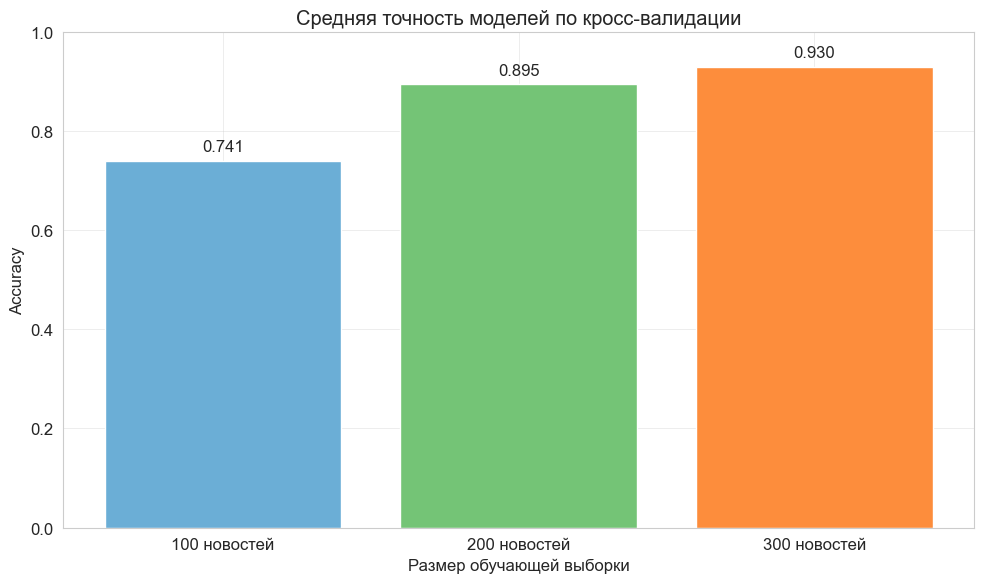

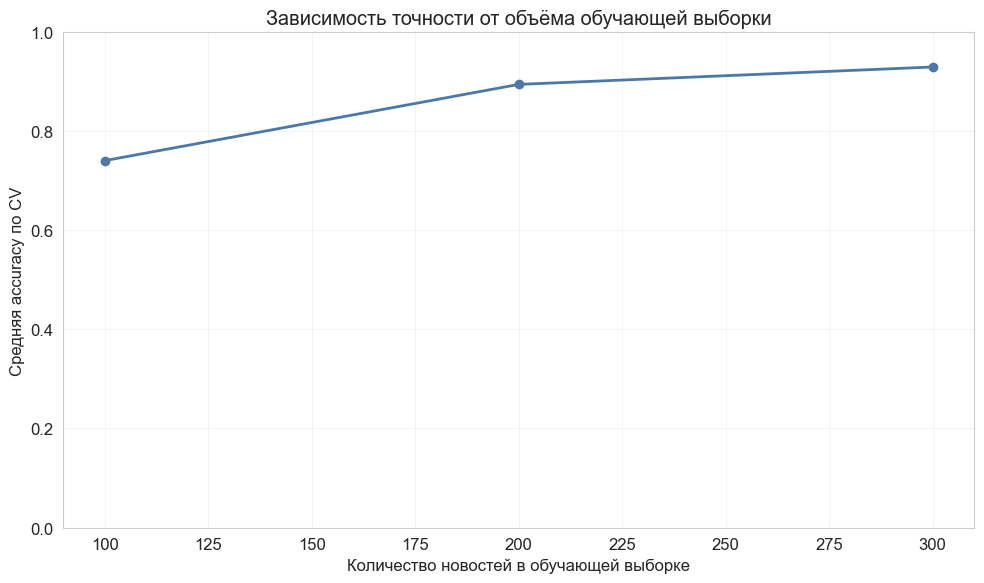

In [4]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    results_df["dataset"],
    results_df["cv_mean_accuracy"],
    color=["#6baed6", "#74c476", "#fd8d3c"],
)

plt.title("Средняя точность моделей по кросс-валидации")
plt.xlabel("Размер обучающей выборки")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for bar, value in zip(bars, results_df["cv_mean_accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
    )

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(
    results_df["news_count"],
    results_df["cv_mean_accuracy"],
    marker="o",
    linewidth=2,
    color="#4c78a8",
)
plt.title("Зависимость точности от объёма обучающей выборки")
plt.xlabel("Количество новостей в обучающей выборке")
plt.ylabel("Средняя accuracy по CV")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()